# Семинар 13

# Stochastic Optimization 2: Scheduler

In [1]:
import numpy as np
import copy
import time
from collections import defaultdict
import matplotlib
import matplotlib.pyplot as plt

In [2]:
import torch
from torch import nn
from torch.optim import Optimizer

In [3]:
import torchvision
import torchvision.datasets as datasets
import torchvision.transforms as transforms

In [4]:
matplotlib.use('Agg')
params = {'legend.fontsize': 20,
          'legend.handlelength': 4,
          "axes.labelsize": 45,
          "xtick.labelsize": 25,
          "ytick.labelsize": 25,
          "lines.linewidth": 4,
           "axes.titlesize":30}
matplotlib.rcParams.update(params)

In [5]:
if torch.cuda.is_available():
    device = torch.device("cuda:0")
else:
    device = torch.device("cpu")
device

device(type='cuda', index=0)

#### Классификация изображений рукописных цифр из MNIST датасета

In [69]:
np.sqrt(X.shape[-1])

28.0

In [75]:
transform=torchvision.transforms.Compose([
        torchvision.transforms.Resize((28,28)),
        torchvision.transforms.ToTensor(),
    ])

train_dataset = datasets.MNIST(root='./data',
                            train=True, download=True,
                            transform=transform)
test_dataset = datasets.MNIST(root='./data',
                           train=False, download=True,
                           transform=transform)


In [76]:
X_ = []
Y_ = []
for x, y in train_dataset:
    X_.append(x)
    Y_.append(y)
X = torch.stack(X_).to(device)
Y = torch.tensor(Y_).view(-1).to(device)

In [77]:
X_ = []
Y_ = []
for x, y in test_dataset:
    X_.append(x)
    Y_.append(y)
X_test = torch.stack(X_).to(device)
Y_test = torch.tensor(Y_).view(-1).to(device)

In [78]:
print("Shape of X train", X.shape)
print("Shape of X test", X_test.shape)
print("Sparsity of X train", (torch.sum(torch.abs(X)>=1e-12)/(X.shape[0] * X.shape[1])).item())

Shape of X train torch.Size([60000, 1, 28, 28])
Shape of X test torch.Size([10000, 1, 28, 28])
Sparsity of X train 149.90260314941406


### Модель

$$F_{W_1\dots W_n} (\mathbf{x}) = \text{Softmax}\left(W_n\sigma\left(W_{n-1}\dots \sigma\left(W_1 \mathbf{x}\right)\dots \right)\right),$$
где $\sigma$ - некоторая функция активации,

$$\text{Softmax}(\mathbf{x}) = \frac{e^\mathbf{x}}{\sum\limits_{i=1}^n e^{x_i}}$$

In [74]:
X.shape

torch.Size([60000, 1, 28, 28])

In [98]:
import torch.nn.functional as F

class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=5)
        self.conv2 = nn.Conv2d(32, 32, kernel_size=5)
        self.conv3 = nn.Conv2d(32,64, kernel_size=5)
        self.fc1 = nn.Linear(3*3*64, 256)
        self.fc2 = nn.Linear(256, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        #x = F.dropout(x, p=0.5, training=self.training)
        x = F.relu(F.max_pool2d(self.conv2(x), 2))
        x = F.dropout(x, p=0.5, training=self.training)
        x = F.relu(F.max_pool2d(self.conv3(x),2))
        x = F.dropout(x, p=0.5, training=self.training)
        x = x.view(-1,3*3*64 )
        x = F.relu(self.fc1(x))
        x = F.dropout(x, training=self.training)
        x = self.fc2(x)
        return x

In [99]:
model = CNN()
model.to(device)
model

CNN(
  (conv1): Conv2d(1, 32, kernel_size=(5, 5), stride=(1, 1))
  (conv2): Conv2d(32, 32, kernel_size=(5, 5), stride=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=576, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=10, bias=True)
)

In [100]:
print("Sum of the first raw of model(x[0])", torch.sum(model(X_test)[0]))
print("Shape of X test", X_test.shape)
print("Shape of X test", model(X_test).shape)

Sum of the first raw of model(x[0]) tensor(0.1395, device='cuda:0', grad_fn=<SumBackward0>)
Shape of X test torch.Size([10000, 1, 28, 28])
Shape of X test torch.Size([10000, 10])


In [183]:
def get_batch_indexes(n, batch_size):
    """
    :param batch_size: int, batch size
    :param n: int, the size of full dataset
    :return: list of batches
    """
    indexes = np.arange(n)
    indexes = np.random.permutation(indexes)
    batches = np.array_split(indexes, n//batch_size)
    return batches


def update_logs(logs, iteration, train_loss, test_loss, time_val):
    """
    :param logs: dict, dictionary for logs
    :param iteration: int, number of iteration
    :param train_loss: float, value of loss on train dataset
    :param test_loss: float, value of loss on test dataset
    :param time_val: float, time from training start
    :return:
    """
    logs['iter'].append(iteration)
    logs['train_loss'].append(train_loss)
    logs['test_loss'].append(test_loss)
    logs['time'].append(time_val)


def train_epochs(model, X, Y, loss, num_epochs,
          optimizer, batch_size,
          scheduler=None, scheduler_in_batch=False,
          X_test=None, Y_test=None):
    """
    :param model: nn.Module, model that should be trained
    :param X: torch.tensor, train dataset, input of model
    :param Y: torch.tensor, train dataset, target for model
    :param loss: callable, that takes model output with target and returns differntiable loss
    :param num_epochs: int, number of epochs
    :param optimizer: optimizer with method step
    :param batch_size: int, batch size
    :param scheduler: scheduler that change lr size
    :param X_test: torch.tensor, test dataset, input of model
    :param Y_test: torch.tensor, test dataset, target for model
    :return: trained model and logs
    """
    n = X.shape[0]
    logs = defaultdict(list)
    t0 = time.time()
    num_iters = 0
    for i in range(num_epochs):
        batches = get_batch_indexes(n, batch_size)
        for batch in batches:
            X_batch, Y_batch = X[batch], Y[batch]
            loss_value = loss(model(X_batch), Y_batch.long())
            loss_value.backward()
            optimizer.step()
            optimizer.zero_grad()
            if scheduler is not None and scheduler_in_batch:
                scheduler.step(epoch=num_iters)
            num_iters+=1
        with torch.no_grad():
            train_loss = loss(model(X), Y.long()).cpu().item()
            if X_test is not None:
                test_loss = loss(model(X_test), Y_test.long()).cpu().item()
            else:
                test_loss = None
        if scheduler is not None and not scheduler_in_batch:
            print(i, scheduler.get_last_lr(), train_loss)
            scheduler.step(epoch=i)
        update_logs(logs, i, train_loss, test_loss, time.time() - t0)
    return model, logs

In [171]:
def plot_logs(logs_dict_vr):
    plt.figure(figsize=(30, 20))
    fig, ax = plt.subplots(1, 2, figsize=(30, 10))
    y_min = None
    for label, logs in logs_dict_vr.items():
        ax[0].semilogy(logs["iter"], logs["train_loss"], label=label)
        ax[1].semilogy(logs["iter"], logs["test_loss"], label=label)
        if y_min is None or y_min > min(logs["test_loss"]):
            y_min = min(logs["test_loss"])
    ax[0].legend()
    ax[0].set_ylabel("Function Value")
    ax[0].set_xlabel("Epoch")
    ax[0].set_title("Loss on Train")
    ax[0].grid()
    ax[1].legend()
    ax[1].set_ylabel("Function Value")
    ax[1].set_xlabel("Epoch")
    ax[1].set_title("Loss on Test")
    ax[1].axhline(y=y_min, color='r', linestyle='--')
    ax[1].grid()

### Schedulers

In [172]:
logs_dict_vr = {}

In [179]:
epochs = 100
batch_size = 512

In [180]:
model=CNN()
model.to(device)
model.to(torch.float32)
optimizer = SGD(model.parameters(), lr=0.8)
_, logs_dict_vr["SGD"] = train_epochs(model, X, Y, nn.CrossEntropyLoss(), epochs, optimizer, batch_size=batch_size, X_test=X_test, Y_test=Y_test)

#### StepLR

Каждые $T$ шагов умножаем размер шага на $\gamma \in (0,1)$:

$\eta^t = \eta_0, t=\overline{0,T-1}$

$\eta^{t+kT} = \gamma^k \eta^0, t=\overline{0,T-1}, k\geq 0$

In [188]:


model=CNN()
model.to(device)
model.to(torch.float32)
optimizer = SGD(model.parameters(), lr=0.5)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, 
                                               step_size=30,
                                               gamma=0.5)
_, logs_dict_vr["SGD, StepLR"] = train_epochs(model, X.to(device), Y.to(device).view(-1).to(torch.long),
                                          nn.CrossEntropyLoss(), epochs, optimizer, batch_size=batch_size, scheduler=lr_scheduler,
                                          X_test=X_test.to(device), Y_test=Y_test.to(device).to(torch.long))

0 [0.5] 0.5690934062004089
1 [0.5] 0.20501361787319183
2 [0.5] 0.15467825531959534
3 [0.5] 0.14448602497577667
4 [0.5] 0.11578847467899323
5 [0.5] 0.09955227375030518
6 [0.5] 0.10411795228719711
7 [0.5] 0.0834038108587265
8 [0.5] 0.07964680343866348
9 [0.5] 0.07671469449996948
10 [0.5] 0.0730845108628273
11 [0.5] 0.06928812712430954
12 [0.5] 0.06381642073392868
13 [0.5] 0.0609457828104496
14 [0.5] 0.057113442569971085
15 [0.5] 0.05534980073571205
16 [0.5] 0.05527575686573982
17 [0.5] 0.05505160987377167
18 [0.5] 0.051390390843153
19 [0.5] 0.05129490792751312
20 [0.5] 0.04829039052128792
21 [0.5] 0.05431252717971802
22 [0.5] 0.04790707305073738
23 [0.5] 0.045786693692207336
24 [0.5] 0.04597257822751999
25 [0.5] 0.044627681374549866
26 [0.5] 0.0439397431910038
27 [0.5] 0.0420805960893631
28 [0.5] 0.04205106571316719
29 [0.5] 0.04051186889410019
30 [0.5] 0.04071366414427757
31 [0.25] 0.037486374378204346
32 [0.25] 0.03654289245605469
33 [0.25] 0.038418956100940704
34 [0.25] 0.035401236265

#### Cosine Annealing LR

Варьируем шаг от $\eta^{\max}$ до $\eta^{\min}$ с некоторой периодичностью:

$\eta^t = \eta^{\min} + \frac{1}{2}(\eta^{\max}-\eta^{\min})(1+\cos\left(\frac{t}{T}\pi\right))$

In [185]:
model=CNN()
model.to(device)
model.to(torch.float32)
optimizer = SGD(model.parameters(), lr=0.5)
lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, 
                                                          T_max=30, 
                                                          verbose=True)
_, logs_dict_vr["SGD, CosineScheduler"] = train_epochs(model, X.to(device), Y.to(device).view(-1).to(torch.long),
                                          nn.CrossEntropyLoss(), epochs, optimizer, batch_size=batch_size, scheduler=lr_scheduler,
                                          X_test=X_test.to(device), Y_test=Y_test.to(device).to(torch.long))

0 [0.5] 0.32276561856269836
1 [0.5] 0.16165412962436676
2 [0.4986304738420683] 0.12348155677318573
3 [0.4945369001834514] 0.11100001633167267
4 [0.4877641290737884] 0.09630269557237625
5 [0.4783863644106502] 0.08290258049964905
6 [0.4665063509461097] 0.07526931166648865
7 [0.45225424859373686] 0.07135577499866486
8 [0.43578620636934856] 0.06673787534236908
9 [0.41728265158971456] 0.0746345967054367
10 [0.3969463130731183] 0.06036863476037979
11 [0.375] 0.05985583737492561
12 [0.3516841607689501] 0.05444958806037903
13 [0.32725424859373686] 0.05241628736257553
14 [0.3019779227044398] 0.05685931444168091
15 [0.2761321158169134] 0.049786534160375595
16 [0.25000000000000006] 0.0469602532684803
17 [0.22386788418308667] 0.04679425060749054
18 [0.19802207729556015] 0.04610372707247734
19 [0.17274575140626316] 0.0452665276825428
20 [0.14831583923105] 0.0433136485517025
21 [0.12500000000000006] 0.04493837431073189
22 [0.10305368692688174] 0.0424150675535202
23 [0.08271734841028552] 0.0439973101

<Figure size 3000x2000 with 0 Axes>

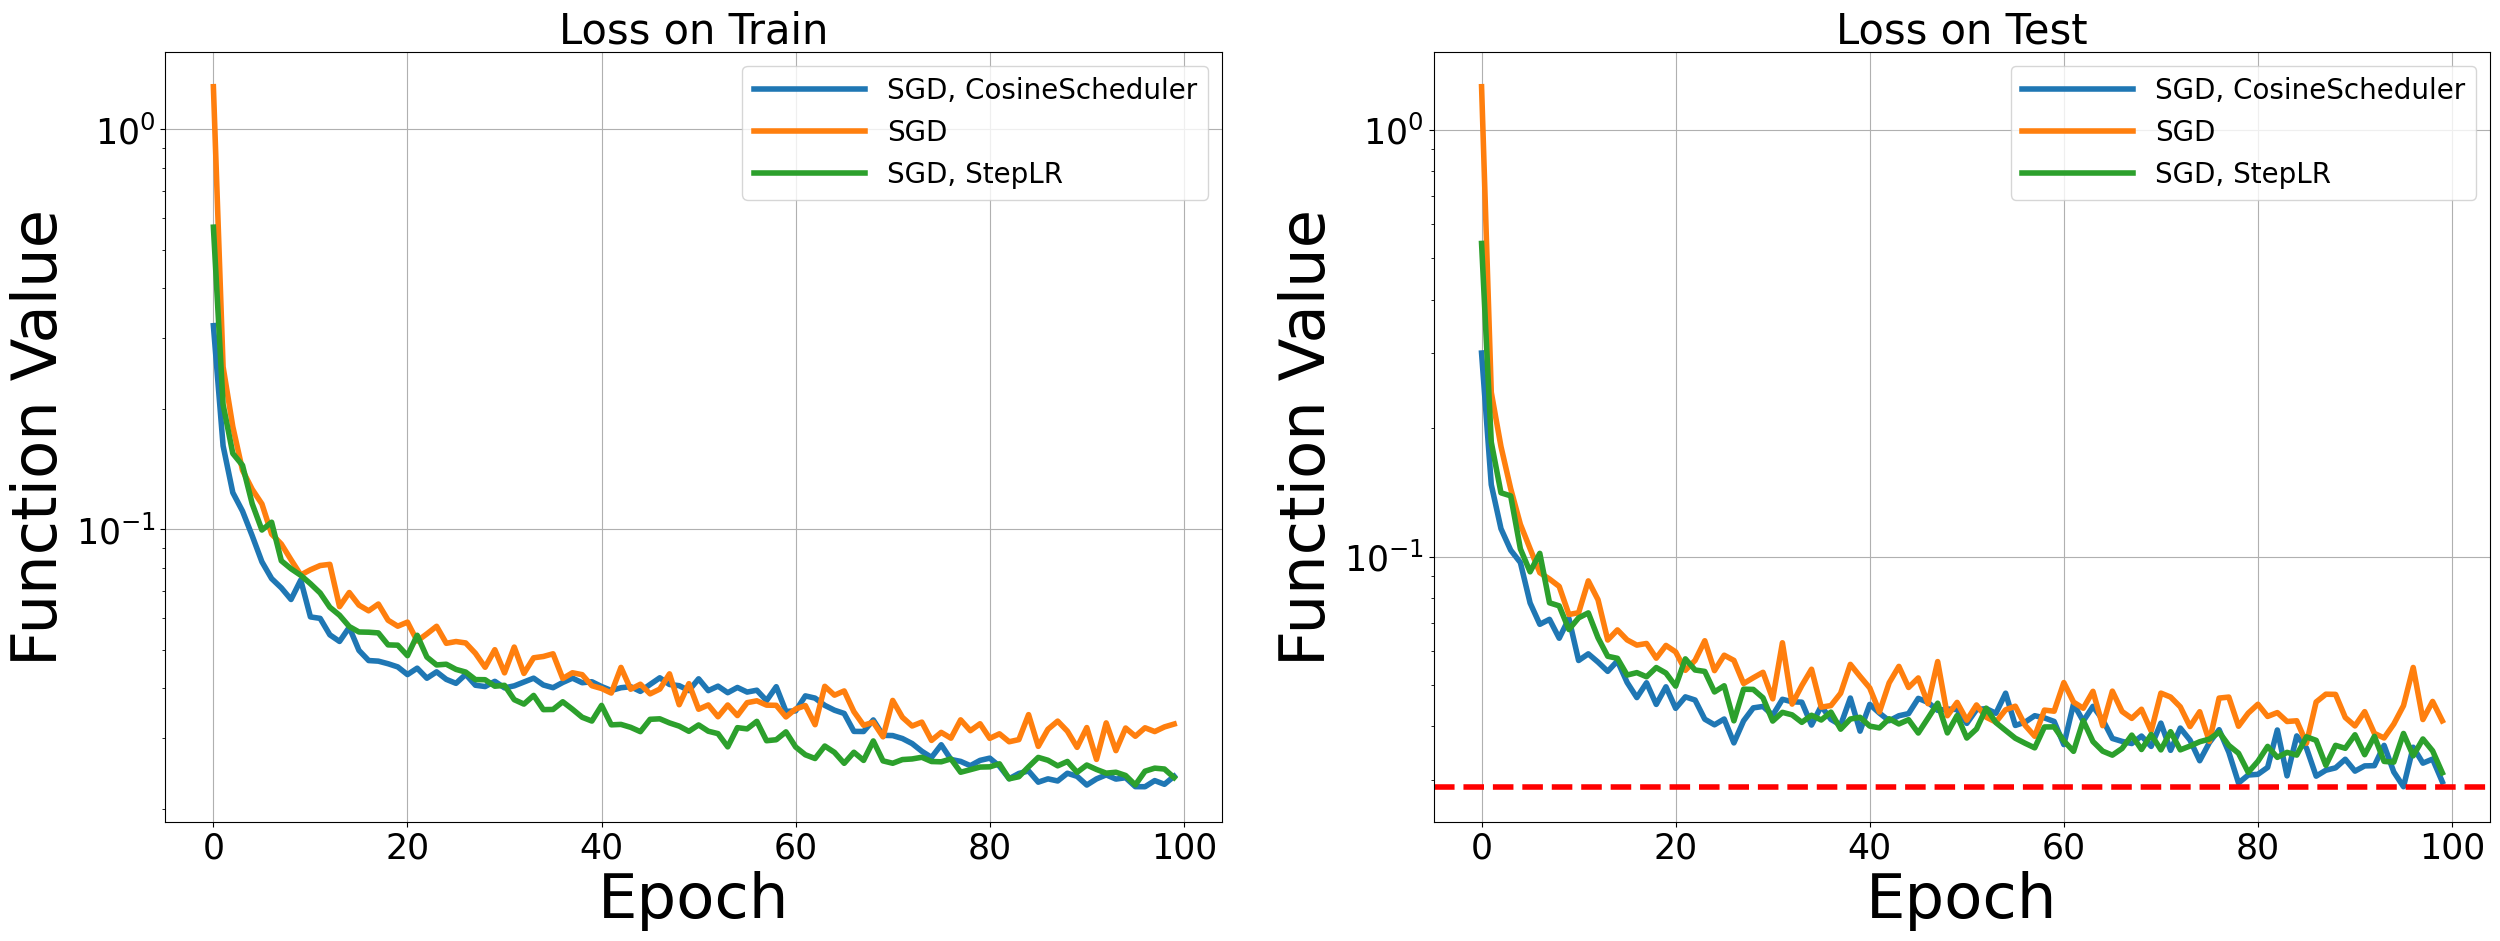

In [189]:
%matplotlib inline
plot_logs(logs_dict_vr)